In [15]:
from training_utils import TrainConfig, train_end_to_end, predict_proba, find_threshold_for_recall, print_reports, load_dataset_csv, split_data
import pandas as pd

In [16]:
df= pd.read_csv('fifth_feature_df_14_01_2026.csv')
df.head(5)

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,GCS_max,GCS_mean,Lactate_min,Lactate_max,Lactate_mean,BUN_min,BUN_mean,...,HR_mean,HR_max,HR_std,RDW_max,RDW_mean,RDW_min,RDW_std,age_adj_comorbidity_score,MEANBP_min,MEANBP_mean
0,3,145834,211552,6.0,4.444444,1.3,8.8,3.800000,36.0,40.500000,...,98.925373,168.0,28.103334,15.7,15.400000,15.0,0.273861,16.0,40.000000,76.728071
1,6,107064,228232,6.0,6.000000,NaN,NaN,NaN,65.0,65.500000,...,84.791667,100.0,5.573334,17.0,16.450000,15.9,0.777817,12.0,72.666702,87.175435
2,9,150750,220597,5.0,2.600000,1.9,2.7,2.380000,17.0,18.500000,...,87.644737,111.0,8.162849,14.3,14.000000,13.8,0.264575,12.0,67.000000,98.289474
3,12,112213,232669,6.0,4.842105,1.6,15.1,8.716667,28.0,35.500000,...,83.208333,105.0,8.518311,14.9,14.625000,14.2,0.309570,7.0,73.000000,96.819444
4,17,194023,277042,6.0,5.615385,0.9,0.9,0.900000,10.0,10.666667,...,82.400000,114.0,11.049719,12.9,12.766667,12.6,0.152753,0.0,53.000000,69.714286


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21247 entries, 0 to 21246
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SUBJECT_ID                 21247 non-null  int64  
 1   HADM_ID                    21247 non-null  int64  
 2   ICUSTAY_ID                 21247 non-null  int64  
 3   GCS_max                    20938 non-null  float64
 4   GCS_mean                   20938 non-null  float64
 5   Lactate_min                11893 non-null  float64
 6   Lactate_max                11893 non-null  float64
 7   Lactate_mean               11893 non-null  float64
 8   BUN_min                    21076 non-null  float64
 9   BUN_mean                   21076 non-null  float64
 10  BUN_max                    21076 non-null  float64
 11  Bilirubin_max              9322 non-null   float64
 12  Bilirubin_mean             9322 non-null   float64
 13  Albumin_mean               8021 non-null   flo

In [19]:
print(df.shape)
print(df.columns.to_list())

(21247, 57)
['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'GCS_max', 'GCS_mean', 'Lactate_min', 'Lactate_max', 'Lactate_mean', 'BUN_min', 'BUN_mean', 'BUN_max', 'Bilirubin_max', 'Bilirubin_mean', 'Albumin_mean', 'Albumin_min', 'Albumin_max', 'AlkPhos_mean', 'AlkPhos_max', 'AlkPhos_min', 'PT_mean', 'PT_min', 'INR_mean', 'INR_min', 'Phosphate_mean', 'Phosphate_max', 'PaO2_mean', 'PaO2_max', 'aPTT_mean', 'aPTT_min', 'MORTALITY_INHOSPITAL', 'MORTALITY_90DAY', 'MORTALITY_180DAY', 'AG_mean', 'AG_max', 'AG_min', 'AG_std', 'SYSBP_min', 'SYSBP_mean', 'SYSBP_std', 'DIASBP_min', 'DIASBP_mean', 'age', 'RR_mean', 'RR_max', 'RR_min', 'TEMP_std', 'TEMP_min', 'HR_mean', 'HR_max', 'HR_std', 'RDW_max', 'RDW_mean', 'RDW_min', 'RDW_std', 'age_adj_comorbidity_score', 'MEANBP_min', 'MEANBP_mean']


In [20]:
df.isnull().sum()

SUBJECT_ID                       0
HADM_ID                          0
ICUSTAY_ID                       0
GCS_max                        309
GCS_mean                       309
Lactate_min                   9354
Lactate_max                   9354
Lactate_mean                  9354
BUN_min                        171
BUN_mean                       171
BUN_max                        171
Bilirubin_max                11925
Bilirubin_mean               11925
Albumin_mean                 13226
Albumin_min                  13226
Albumin_max                  13226
AlkPhos_mean                 12159
AlkPhos_max                  12159
AlkPhos_min                  12159
PT_mean                       2526
PT_min                        2526
INR_mean                      2524
INR_min                       2524
Phosphate_mean                1303
Phosphate_max                 1303
PaO2_mean                     6210
PaO2_max                      6210
aPTT_mean                     2586
aPTT_min            

## Config
Changeable values to train a different dataset.

In [21]:
DATASET_PATH = "fifth_feature_df_14_01_2026.csv"   # <-- change
TARGET_COL   = "MORTALITY_INHOSPITAL"                     # <-- change
DROP_COLS    = ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID",'MORTALITY_90DAY', 'MORTALITY_180DAY'] # optional
TARGET_RECALL = 0.90

cfg = TrainConfig(
    target_col=TARGET_COL,
    drop_cols=DROP_COLS,
    target_recall=TARGET_RECALL,
    test_size=0.2,
    random_state=42
)


## Train + Select Best Model (AP then AUROC)

In [22]:
results = train_end_to_end(DATASET_PATH, cfg)

best_name = results["best_name"]
best_model = results["best_model"]
metrics = results["metrics"]
X_val, y_val = results["val"]

print("Models trained:", list(metrics.keys()))
print("\nMetrics (threshold tuned for recall>=target):")
display(pd.DataFrame(metrics).T.sort_values(["ap", "auroc"], ascending=False))


Models trained: ['logreg', 'dt', 'rf', 'xgb']

Metrics (threshold tuned for recall>=target):


,ap,auroc,threshold
xgb,0.505999,0.848839,0.058821
rf,0.456337,0.835599,0.085000
logreg,0.444015,0.825187,0.302151
dt,0.343385,0.773656,0.427064


## Evaluate Best Model (Detailed Report)

In [23]:
y_prob = predict_proba(best_model, X_val)
thr = find_threshold_for_recall(y_val, y_prob, cfg.target_recall)

print(f"Best model: {best_name}")
print(f"Chosen threshold (target recall={cfg.target_recall}): {thr:.4f}\n")

print_reports(y_val, y_prob, threshold=thr)


Best model: xgb
Chosen threshold (target recall=0.9): 0.0588

Confusion matrix:
 [[2201 1489]
 [  56  504]]

Classification report:
               precision    recall  f1-score   support

           0     0.9752    0.5965    0.7402      3690
           1     0.2529    0.9000    0.3948       560

    accuracy                         0.6365      4250
   macro avg     0.6140    0.7482    0.5675      4250
weighted avg     0.8800    0.6365    0.6947      4250



Num columns in X_train: 51
Num importances: 51
Best model: xgb
                      feature  importance
0                     GCS_max    0.095174
26                    AG_mean    0.061976
4                Lactate_mean    0.042288
5                     BUN_min    0.040708
48  age_adj_comorbidity_score    0.035591
1                    GCS_mean    0.030728
2                 Lactate_min    0.027013
30                  SYSBP_min    0.026114
35                        age    0.024821
12                Albumin_max    0.023025
36                    RR_mean    0.022322
8               Bilirubin_max    0.021628
19                    INR_min    0.021338
27                     AG_max    0.021175
10               Albumin_mean    0.020220
9              Bilirubin_mean    0.019877
22                  PaO2_mean    0.017659
44                    RDW_max    0.017530
3                 Lactate_max    0.017413
31                 SYSBP_mean    0.017114
28                     AG_min    0.016436
39           

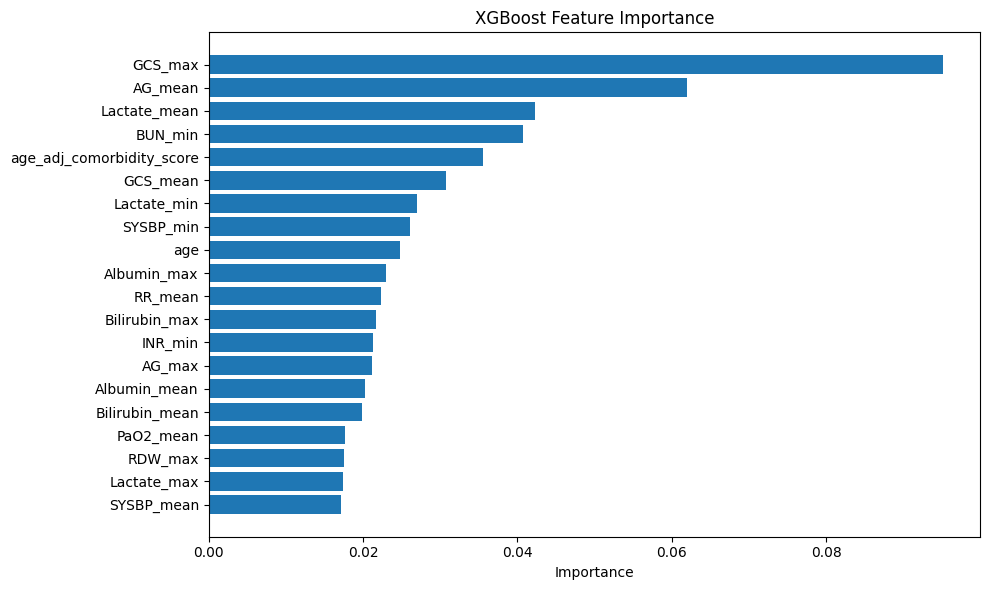

In [24]:
#Feature importance of XGBoost
import matplotlib.pyplot as plt

X, y= load_dataset_csv(DATASET_PATH, TARGET_COL, DROP_COLS)

X_train, X_val, y_train, y_val = split_data(
    X, y,
    test_size=cfg.test_size,
    random_state=cfg.random_state
)


best_model = results["best_model"]
xgb_fitted = best_model.named_steps["model"]

importance = xgb_fitted.feature_importances_

print("Num columns in X_train:", X_train.shape[1])
print("Num importances:", len(importance))
print("Best model:", results["best_name"])


fi_xgb = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(fi_xgb)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(fi_xgb["feature"].head(20)[::-1],
         fi_xgb["importance"].head(20)[::-1])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


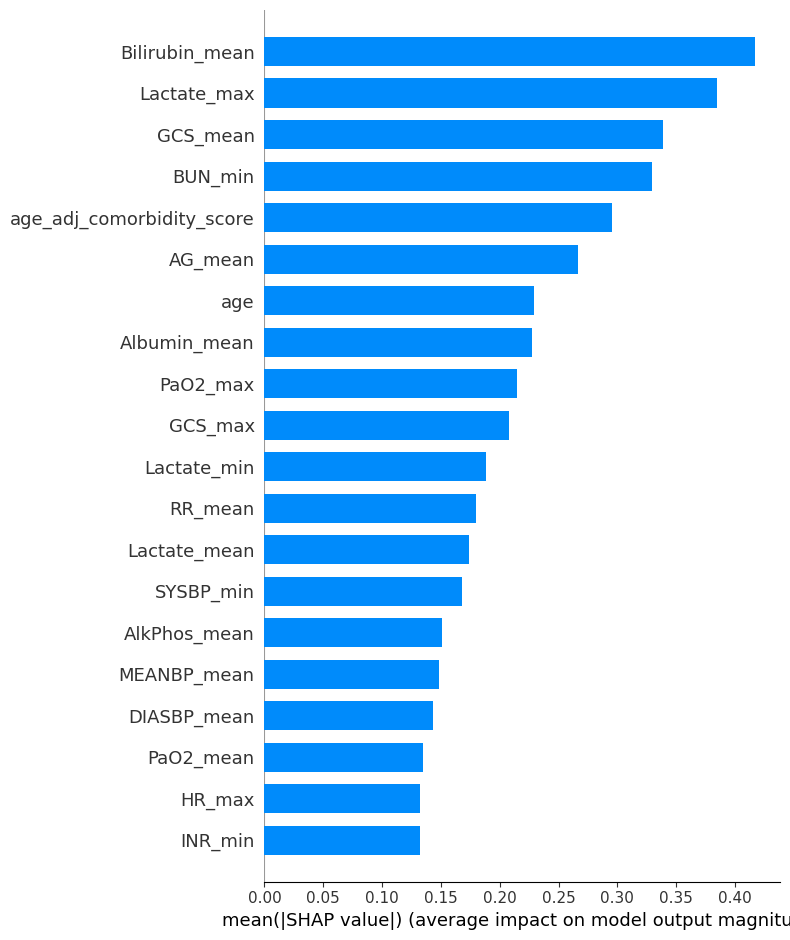

In [25]:
# SHAP summary plot showing global feature importance for the final XGBoost model
import shap

explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar")

In [26]:
# Save Best Model (joblib)
from pathlib import Path
import joblib

BASE_DIR = Path.cwd()   
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "fifth_feature_mortality_inhospital.joblib"


joblib.dump(best_model, model_path)

print(f"Model saved at: {model_path}")



Model saved at: d:\Python Essential\Data Science II project\Fifh_feature\models\fifth_feature_mortality_inhospital.joblib


In [24]:
# import joblib
# from pathlib import Path

# OUT_DIR = Path("artifacts")
# OUT_DIR.mkdir(exist_ok=True)

# out_path = OUT_DIR / f"best_model_{best_name}.joblib"
# joblib.dump(best_model, out_path)

# print("Saved to:", out_path)


## Load Saved Model (Example)